In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
print(nx.__version__)

3.5


In [42]:
#batch = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_100.npz')
batch = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_gmm_params/batch_2.npz')
print(batch.files)
idx = np.random.randint(0, 100)
n_a = batch['acc_xy'][idx].shape[0]
adj_mat = batch['adj_mat'][idx][:n_a, :n_a]

g = nx.from_numpy_array(adj_mat)
n_nodes = g.number_of_nodes()
n_edges = g.number_of_edges()

local_clustering = nx.clustering(g)
for v, c in list(local_clustering.items())[:10]:
    print(v, c)

avg_clustering = nx.average_clustering(g)
print(f'Average clustering: {avg_clustering}')

print(n_nodes)
print(n_edges)

edge_density = n_edges / (n_nodes * (n_nodes - 1))

['out_idx', 'currents', 'inputs', 'sampleStd', 'sem', 'acc_xy', 'don_xy', 'init_en', 'rand_en', 'acc_don', 'acc_acc', 'rate_pref', 'adj_mat', 'variances', 'means', 'norm_weights']
0 0.7497584541062802
1 0.5219170075978959
2 0.8396825396825397
3 0.8677248677248677
4 0.6522108843537415
5 0.6712626995645864
6 0.6180235535074244
7 0.8689458689458689
8 0.779874213836478
9 0.6591591591591591
Average clustering: 0.7267021904602206
200
4421


In [28]:
L = nx.laplacian_matrix(g)
L_dense = L.toarray()

eigvs = nx.laplacian_spectrum(g)
num_connected_comps = np.isclose(eigvs, 0).sum()
print(num_connected_comps)
print(nx.number_connected_components(g))

eigvs_sorted = np.sort(eigvs)

lambda_1 = eigvs_sorted[0]   # ≈ 0
lambda_2 = eigvs_sorted[1]   # algebraic connectivity
print("lambda_1:", lambda_1)
print("lambda_2:", lambda_2)

1
1
lambda_1: -3.5527136788005035e-14
lambda_2: 1.8142691694977682


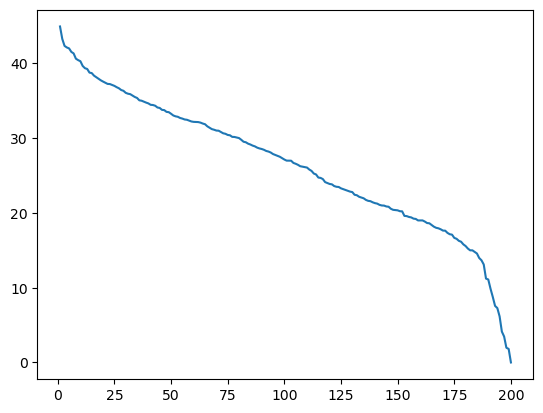

In [29]:
eigvs_sorted = np.sort(eigvs)[::-1]

x = np.arange(1, len(eigvs_sorted)+1)

plt.plot(x, eigvs_sorted)

In [43]:
num_graphs = batch['adj_mat'].shape[0]

edge_densities = []
avg_degs = []
avg_clustering = []

for i in range(300):
    A_i = batch['adj_mat'][i][:n_a, :n_a]
    m_i = np.count_nonzero(np.triu(A_i, k=1))
    rho_i = 2*m_i / (n_a * (n_a - 1))
    avg_deg_i = 2 * m_i / n_a
    
    edge_densities.append(rho_i)
    avg_degs.append(avg_deg_i)

    g = nx.from_numpy_array(A_i)
    avg_clst_i = nx.average_clustering(g)
    avg_clustering.append(avg_clst_i)
print('Done')

Done


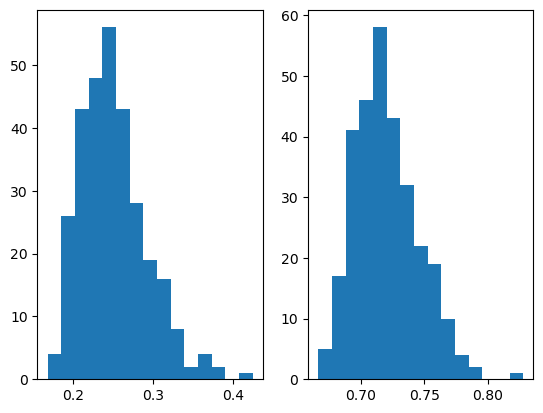

In [44]:
fig, ax = plt.subplots(ncols=2)
ax[0].hist(edge_densities, bins=15)
ax[1].hist(avg_clustering, bins=15)

plt.show()